Dataset - Diabetes (skikit - learn)

In [4]:
from sklearn.datasets import load_diabetes
import pandas as pd

# Load dataset
diabetes = load_diabetes()

print("Feature Names:")
print(diabetes.feature_names)




Feature Names:
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


SINGLE LINEAR REGRESSION

Slope (b1): 998.5776891375596
Intercept (b0): 152.00335421448167


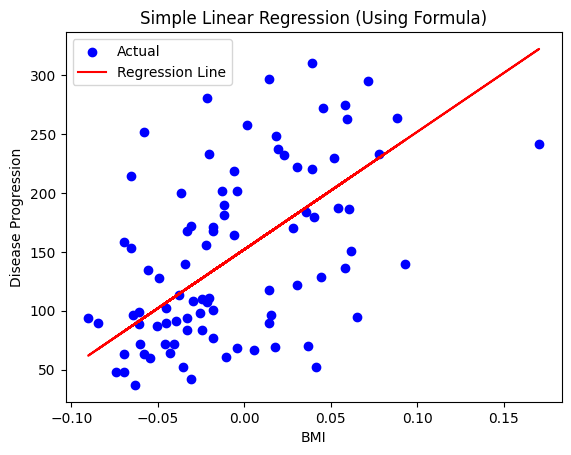

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load dataset
diabetes = load_diabetes()
X = diabetes.data[:, 2]   # BMI feature
y = diabetes.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------- FORMULA IMPLEMENTATION -----------

mean_x = np.mean(X_train)
mean_y = np.mean(y_train)

mean_xy = np.mean(X_train * y_train)
mean_x2 = np.mean(X_train * X_train)

# Calculate b1 (slope)
b1 = (mean_xy - mean_x * mean_y) / (mean_x2 - mean_x**2)

# Calculate b0 (intercept)
b0 = mean_y - b1 * mean_x

print("Slope (b1):", b1)
print("Intercept (b0):", b0)

# Prediction
y_pred = b0 + b1 * X_test

# Plot
plt.scatter(X_test, y_test, color="blue", label="Actual")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Simple Linear Regression (Using Formula)")
plt.legend()
plt.show()


Multi Linear Regression

In [5]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Load dataset
diabetes = load_diabetes()
X = diabetes.data
Y = diabetes.target
feature_names = diabetes.feature_names

# Train-test split
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Add bias column (for b0)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]

# Apply Least Squares Formula
b = np.linalg.inv(X_train_b.T @ X_train_b) @ X_train_b.T @ Y_train

# -------- Formal Output --------
print("Regression Coefficients:\n")

print(f"b0 (Intercept) = {b[0]:.4f}")

for i in range(1, len(b)):
    print(f"b{i} ({feature_names[i-1]}) = {b[i]:.4f}")


Regression Coefficients:

b0 (Intercept) = 151.3456
b1 (age) = 37.9040
b2 (sex) = -241.9644
b3 (bmi) = 542.4288
b4 (bp) = 347.7038
b5 (s1) = -931.4888
b6 (s2) = 518.0623
b7 (s3) = 163.4200
b8 (s4) = 275.3179
b9 (s5) = 736.1989
b10 (s6) = 48.6707
